In [ ]:
import pandas as pd
import math
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [2]:
# Load raw data
dfs_raw = load_signal_data(search_folder="RawMeasurements/2024-06-01_2024-10-31/G2_relevant")

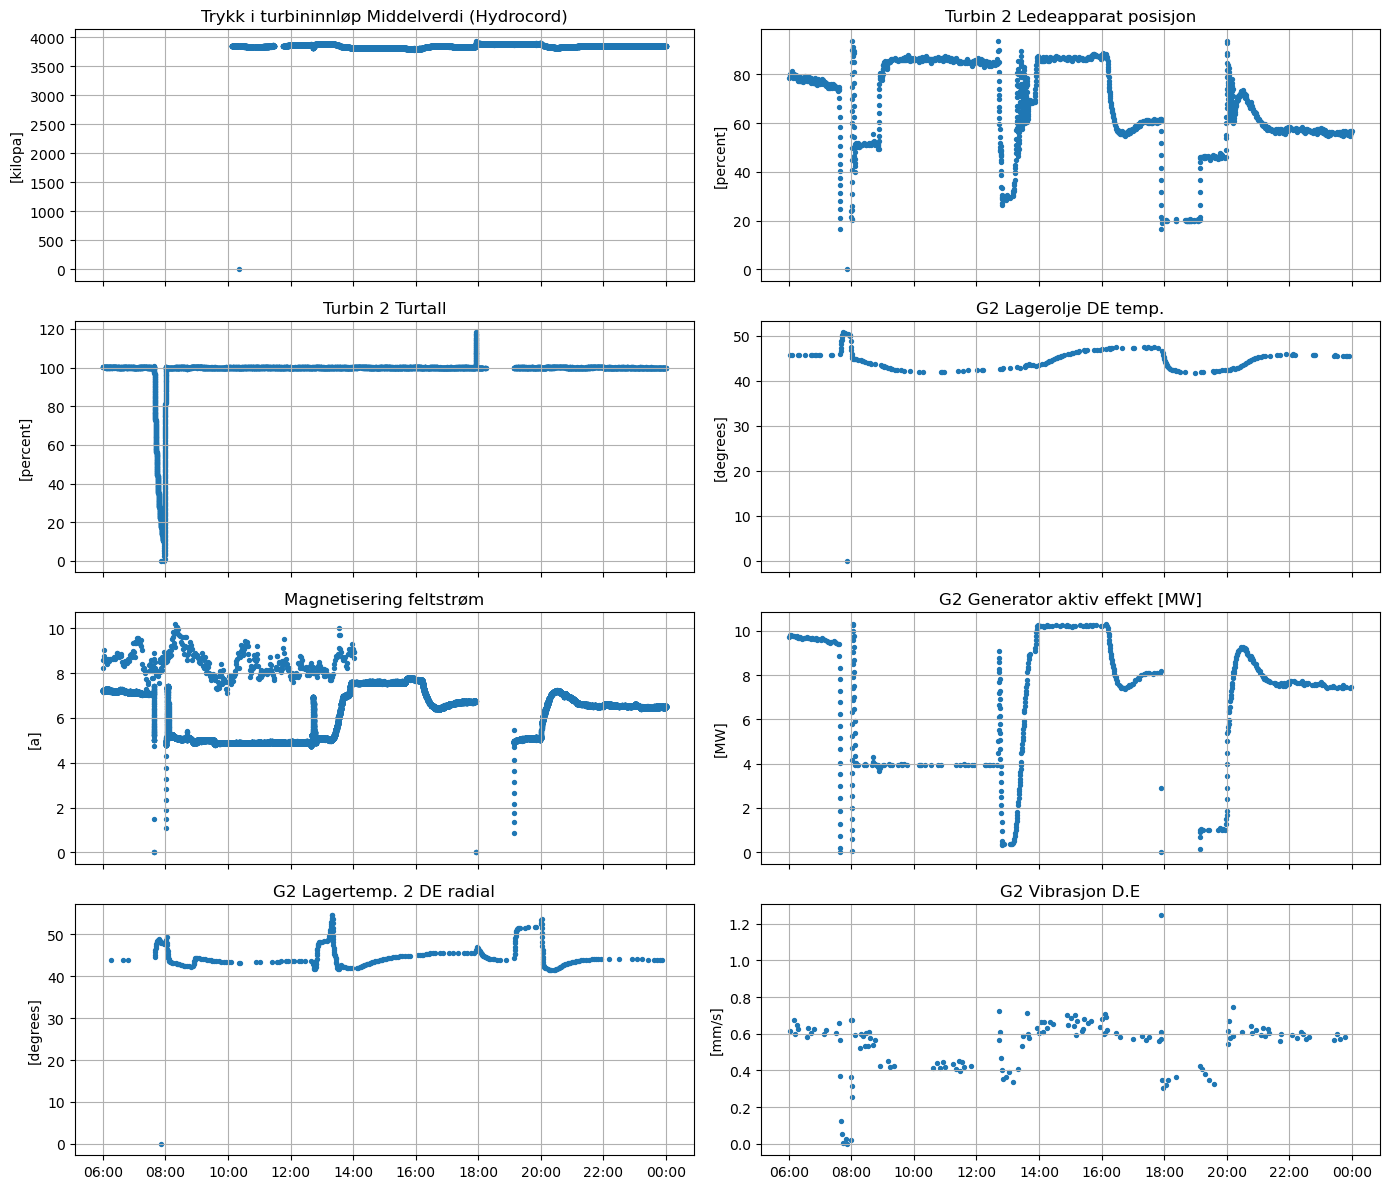

In [ ]:
start_time = pd.Timestamp("2024-06-03 06:00:00")
end_time = start_time + pd.Timedelta(hours=18)

n_cols = 2
n_rows = math.ceil(len(dfs_raw) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3*n_rows), sharex=True)
axes = axes.flatten()

for ax, (_, row) in zip(axes, dfs_raw.iterrows()):
    df_plot = row["signal_df"][
        row["signal_df"]["Datetime"].between(start_time, end_time)
    ]

    unit = "Value" if pd.isna(row["unit"]) else str(row["unit"]).split(":")[-1]

    ax.scatter(df_plot["Datetime"], df_plot["signal"], s=8)
    ax.set_title(row["name"])
    ax.set_ylabel(f"[{unit}]" if unit != "Value" else "Value")
    ax.grid(True)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

for ax in axes[len(dfs_raw):]:
    ax.remove()

plt.tight_layout()
plt.savefig("raw_signal_scatter_plot.png", dpi=300, bbox_inches="tight")
plt.show()